In [1]:
import pandas as pd, numpy as np, matplotlib, matplotlib.pyplot as plt, seaborn as sns
import os, warnings, joblib
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVR, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

In [10]:
# matplotlib.rcParams['font.family'] = 'Malgun Gothic'
# matplotlib.rcParams['axes.unicode_minus'] = False
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')


## 1. csv 파일 읽기,  코드북에 따라 변수 뽑기

In [39]:
import pandas as pd

# 데이터 로드
df = pd.read_csv('KCYPS2018m1Yw1.csv')

# 1. 독립 변수 (수면, 스마트폰)
features = [
    'YTIM1A01w1', 'YTIM1A02w1', 'YTIM1B01w1', 'YTIM1B02w1', # 평일 수면
    'YTIM1A03w1', 'YTIM1A04w1', 'YTIM1B03w1', 'YTIM1B04w1', # 주말 수면
    'YTIM1C01w1', 'YTIM1C02w1',                         # 수면의 질
    'YTIM1K01w1', 'YTIM1K02w1'                          # 스마트폰 시간
]

# 2. 종속 변수 후보 (학업 무기력 문항들)
targets = ['YINT2B02w1', 'YINT2B04w1', 'YINT2B05w1', 'YINT2B06w1', 'YINT2B07w1']

# 데이터 추출
final_df = df[['ID'] + features + targets]

print("데이터 추출 완료!")
print(final_df)

데이터 추출 완료!
      ID  YTIM1A01w1  YTIM1A02w1  YTIM1B01w1  YTIM1B02w1  YTIM1A03w1  \
0   7802           5          50          21          30           8   
1  11922           8           0          23           0          11   
2  11932           7          30          22          10          10   
3  12852           7          10          21          30           9   
4  15902           6          30          22          30           7   

   YTIM1A04w1  YTIM1B03w1  YTIM1B04w1  YTIM1C01w1  YTIM1C02w1  YTIM1K01w1  \
0          30          22           0           3           4           6   
1          40          25           0           1           1           5   
2           0          22          30           4           4           4   
3           0          22          30           4           4           2   
4          20          22          30           4           4           6   

   YTIM1K02w1  YINT2B02w1  YINT2B04w1  YINT2B05w1  YINT2B06w1  YINT2B07w1  
0           7    

In [43]:
print(final_df.shape)

(2590, 18)


In [ ]:

# 1. 독립 변수 (수면, 스마트폰)
features = [
    'YTIM1A01w1', 'YTIM1A02w1', 'YTIM1B01w1', 'YTIM1B02w1', # 평일 수면
    'YTIM1A03w1', 'YTIM1A04w1', 'YTIM1B03w1', 'YTIM1B04w1', # 주말 수면
    'YTIM1C01w1', 'YTIM1C02w1',                         # 수면의 질
    'YTIM1K01w1', 'YTIM1K02w1'                          # 스마트폰 시간
]

# 2. 종속 변수 후보 (학업 무기력 문항들)
targets = ['YINT2B02w1', 'YINT2B04w1', 'YINT2B05w1', 'YINT2B06w1', 'YINT2B07w1']

# 데이터 추출
final_df = df[['ID'] + features + targets]


In [41]:
# 1. 독립 변수 (수면, 스마트폰)
features = [
    'YTIM1A01w1', 'YTIM1A02w1', 'YTIM1B01w1', 'YTIM1B02w1', # 평일 수면
    'YTIM1A03w1', 'YTIM1A04w1', 'YTIM1B03w1', 'YTIM1B04w1', # 주말 수면
    'YTIM1C01w1', 'YTIM1C02w1',                         # 수면의 질
    'YTIM1K01w1', 'YTIM1K02w1'                          # 스마트폰 시간
]

# 2. 종속 변수 후보 (학업 무기력 문항들)
targets = ['YINT2B02w1', 'YINT2B04w1', 'YINT2B05w1', 'YINT2B06w1', 'YINT2B07w1']


In [45]:
final_df

,ID,YTIM1A01w1,YTIM1A02w1,YTIM1B01w1,YTIM1B02w1,YTIM1A03w1,YTIM1A04w1,YTIM1B03w1,YTIM1B04w1,YTIM1C01w1,YTIM1C02w1,YTIM1K01w1,YTIM1K02w1,YINT2B02w1,YINT2B04w1,YINT2B05w1,YINT2B06w1,YINT2B07w1
0,7802,5,50,21,30,8,30,22,0,3,4,6,7,1,1,1,1,1
1,11922,8,0,23,0,11,40,25,0,1,1,5,6,4,4,4,4,3
2,11932,7,30,22,10,10,0,22,30,4,4,4,5,1,1,1,1,1
3,12852,7,10,21,30,9,0,22,30,4,4,2,3,2,2,3,3,3
4,15902,6,30,22,30,7,20,22,30,4,4,6,6,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5175,51571,7,30,23,30,12,30,29,30,2,3,6,7,1,2,4,4,2
5176,51581,7,30,23,0,9,0,22,0,3,3,2,2,1,1,1,1,1
5177,51591,7,40,22,0,8,20,22,0,4,4,5,6,1,1,2,2,2
5178,51601,7,30,23,0,8,10,24,0,4,4,5,6,1,1,1,1,1


## 2. 변수 이름 바꾸기

In [46]:
rename_dict = {
    'YTIM1A01w1': '평일_기상_시', 'YTIM1A02w1': '평일_기상_분',
    'YTIM1B01w1': '평일_취침_시', 'YTIM1B02w1': '평일_취침_분',
    'YTIM1A03w1': '주말_기상_시', 'YTIM1A04w1': '주말_기상_분',
    'YTIM1B03w1': '주말_취침_시', 'YTIM1B04w1': '주말_취침_분',
    'YTIM1C01w1': '평일_수면질', 'YTIM1C02w1': '주말_수면질',
    'YTIM1K01w1': '평일_스마트폰시간', 'YTIM1K02w1': '주말_스마트폰시간',
    'YINT2B02w1': '학업_성적한계', 'YINT2B04w1': '학업_통제불가',
    'YINT2B05w1': '학업_회피의도', 'YINT2B06w1': '학업_관심부족',
    'YINT2B07w1': '학업_목표상실'
}
final_df.rename(columns=rename_dict, inplace=True)
final_df[:2]

,ID,평일_기상_시,평일_기상_분,평일_취침_시,평일_취침_분,주말_기상_시,주말_기상_분,주말_취침_시,주말_취침_분,평일_수면질,주말_수면질,평일_스마트폰시간,주말_스마트폰시간,학업_성적한계,학업_통제불가,학업_회피의도,학업_관심부족,학업_목표상실
0,7802,5,50,21,30,8,30,22,0,3,4,6,7,1,1,1,1,1
1,11922,8,0,23,0,11,40,25,0,1,1,5,6,4,4,4,4,3


In [47]:
final_df.to_csv("data.csv", index=False)

In [48]:
data = final_df.copy()

In [51]:
import numpy as np
# # 결측치 처리 (9, 99, 999 등 무응답 처리)
# data = data.replace([9, 99, 999], np.nan).dropna()

# 수면 시간 계산 함수 (익일 기상 고려)
def calc_sleep_duration(h_sleep, m_sleep, h_wake, m_wake):
    sleep_time = h_sleep * 60 + m_sleep
    wake_time = h_wake * 60 + m_wake
    if wake_time < sleep_time:
        return (1440 - sleep_time) + wake_time
    else:
        return wake_time - sleep_time

data['평일_총수면분'] = data.apply(lambda x: calc_sleep_duration(
    x['평일_취침_시'], x['평일_취침_분'], x['평일_기상_시'], x['평일_기상_분']), axis=1)
data['주말_총수면분'] = data.apply(lambda x: calc_sleep_duration(
    x['주말_취침_시'], x['주말_취침_분'], x['주말_기상_시'], x['주말_기상_분']), axis=1)

# 종속 변수(y) 생성: 학업 스트레스 지수 (5개 문항 합산)
target_cols = ['학업_성적한계', '학업_통제불가', '학업_회피의도', '학업_관심부족', '학업_목표상실']
data['학업_스트레스_지수'] = data[target_cols].sum(axis=1)

# 분석용 최종 데이터프레임 구성
final_cols = ['ID', '평일_수면질', '주말_수면질', '평일_스마트폰시간', '주말_스마트폰시간', 
              '평일_총수면분', '주말_총수면분', '학업_스트레스_지수']
df1 = data[final_cols]


In [52]:
df1

,ID,평일_수면질,주말_수면질,평일_스마트폰시간,주말_스마트폰시간,평일_총수면분,주말_총수면분,학업_스트레스_지수
0,7802,3,4,6,7,500,630,5
1,11922,1,1,5,6,540,640,19
2,11932,4,4,4,5,560,690,5
3,12852,4,4,2,3,580,630,13
4,15902,4,4,6,6,480,530,5
...,...,...,...,...,...,...,...,...
5175,51571,2,3,6,7,480,420,13
5176,51581,3,3,2,2,510,660,5
5177,51591,4,4,5,6,580,620,8
5178,51601,4,4,5,6,510,490,5


In [ ]:
df1.to_read_csv("data.csv", index=False)

## 데이터 로드 및 검증

In [7]:

BASE_DIR = r'D:\KCYPS2018'
FIG_DIR = os.path.join(BASE_DIR, 'figures')
MDL_DIR = os.path.join(BASE_DIR, 'models')
OUT_DIR = os.path.join(BASE_DIR, 'outputs')
for d in [FIG_DIR, MDL_DIR, OUT_DIR]:
    os.makedirs(d, exist_ok=True)


print('\n[1] 데이터 로드 및 검증')
df = pd.read_csv("data.csv")
print(f'  원본 행수: {len(df)}')
print(f'  컬럼: {list(df.columns)}')
print(f'\n  dtype:\n{df.dtypes}')

missing = df.isnull().sum()
if missing.any():
    print(f'\n  결측치:\n{missing[missing > 0]}')
else:
    print('  결측치: 없음')

# 비현실 수면시간 제거
before = len(df)
df = df[
    (df['평일_총수면분'] >= 120) & (df['평일_총수면분'] <= 900) &
    (df['주말_총수면분'] >= 120) & (df['주말_총수면분'] <= 900)
].reset_index(drop=True)
after = len(df)
print(f'  비현실 수면시간 제거: {before - after}행 제거 → 잔여 {after}행')


[1] 데이터 로드 및 검증
  원본 행수: 5180
  컬럼: ['ID', '평일_수면질', '주말_수면질', '평일_스마트폰시간', '주말_스마트폰시간', '평일_총수면분', '주말_총수면분', '학업_스트레스_지수']

  dtype:
ID            int64
평일_수면질        int64
주말_수면질        int64
평일_스마트폰시간     int64
주말_스마트폰시간     int64
평일_총수면분       int64
주말_총수면분       int64
학업_스트레스_지수    int64
dtype: object
  결측치: 없음
  비현실 수면시간 제거: 10행 제거 → 잔여 5170행


## EDA 분석


In [8]:
# 기술통계 저장
desc = df.describe().T
desc_path = os.path.join(OUT_DIR, 'eda_desc.csv')
desc.to_csv(desc_path, encoding='utf-8-sig')
print(f'  기술통계 저장: {desc_path}')

# 왜도/첨도
num_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'ID' in num_cols:
    num_cols.remove('ID')
print('\n  왜도/첨도:')
for col in num_cols:
    sk = df[col].skew()
    ku = df[col].kurt()
    print(f'    {col}: 왜도={sk:.3f}, 첨도={ku:.3f}')


  기술통계 저장: D:\KCYPS2018/outputs/eda_desc.csv

  왜도/첨도:
    평일_수면질: 왜도=-0.425, 첨도=0.184
    주말_수면질: 왜도=-0.707, 첨도=0.393
    평일_스마트폰시간: 왜도=-0.045, 첨도=-0.280
    주말_스마트폰시간: 왜도=-0.585, 첨도=-0.252
    평일_총수면분: 왜도=-0.495, 첨도=1.875
    주말_총수면분: 왜도=0.116, 첨도=0.682
    학업_스트레스_지수: 왜도=0.500, 첨도=0.094


In [24]:
!fc-list| grep Nanum
font_path = "/usr/share/fonts/truetype/naum/NanumGothic.ttf" 
             /usr/share/fonts/truetype/nanum/NanumGothic.ttf

/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf: NanumSquareRound,나눔스퀘어라운드,NanumSquareRound Bold,나눔스퀘어라운드 Bold:style=Bold,Regular
/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf: NanumGothicCoding,나눔고딕코딩:style=Bold
/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf: NanumSquareRound,나눔스퀘어라운드,NanumSquareRound Regular,나눔스퀘어라운드 Regular:style=Regular
/usr/share/fonts/truetype/nanum/NanumSquareB.ttf: NanumSquare,나눔스퀘어,NanumSquare Bold,나눔스퀘어 Bold:style=Bold
/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf: NanumBarunGothic,나눔바른고딕:style=Regular
/usr/share/fonts/truetype/nanum/NanumGothic.ttf: NanumGothic,나눔고딕:style=Regular
/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf: NanumGothicCoding,나눔고딕코딩:style=Regular
/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf: NanumBarunGothic,나눔바른고딕:style=Bold
/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf: NanumGothic,나눔고딕:style=Bold
/usr/share/fonts/truetype/nanum/NanumSquareR.ttf: NanumSquare,나눔스퀘어:style=Regular
/us

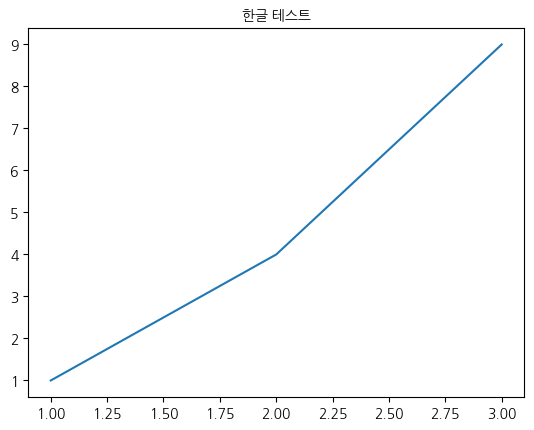

In [25]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# WSL 내부에 설치된 Naum 폰트 경로 확인
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"  # 실제 경로 확인 필요
fontprop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = fontprop.get_name()

# 테스트용 그래프
plt.plot([1,2,3], [1,4,9])
plt.title("한글 테스트", fontproperties=fontprop)
plt.show()


##   학업스트레스 지수 분포

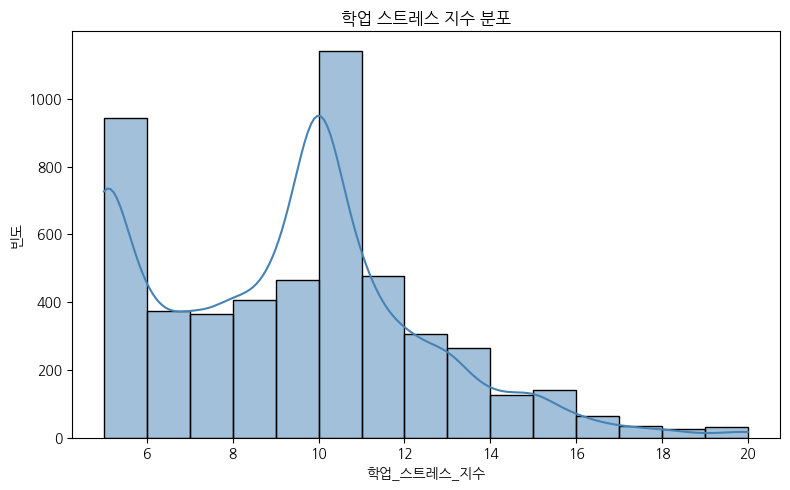

  저장: eda_target_dist.png


In [29]:
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf" 
fontprop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = fontprop.get_name()
matplotlib.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['학업_스트레스_지수'], kde=True, ax=ax, color='steelblue', bins=15)
ax.set_title('학업 스트레스 지수 분포')
ax.set_xlabel('학업_스트레스_지수')
ax.set_ylabel('빈도')
plt.tight_layout()
fig_dir = os.path.join(BASE_DIR, 'figures')
plt.show()
plt.savefig(os.path.join(fig_dir, 'eda_target_dist.png'), dpi=150)
plt.close()
print('  저장: eda_target_dist.png')

##  상관계수

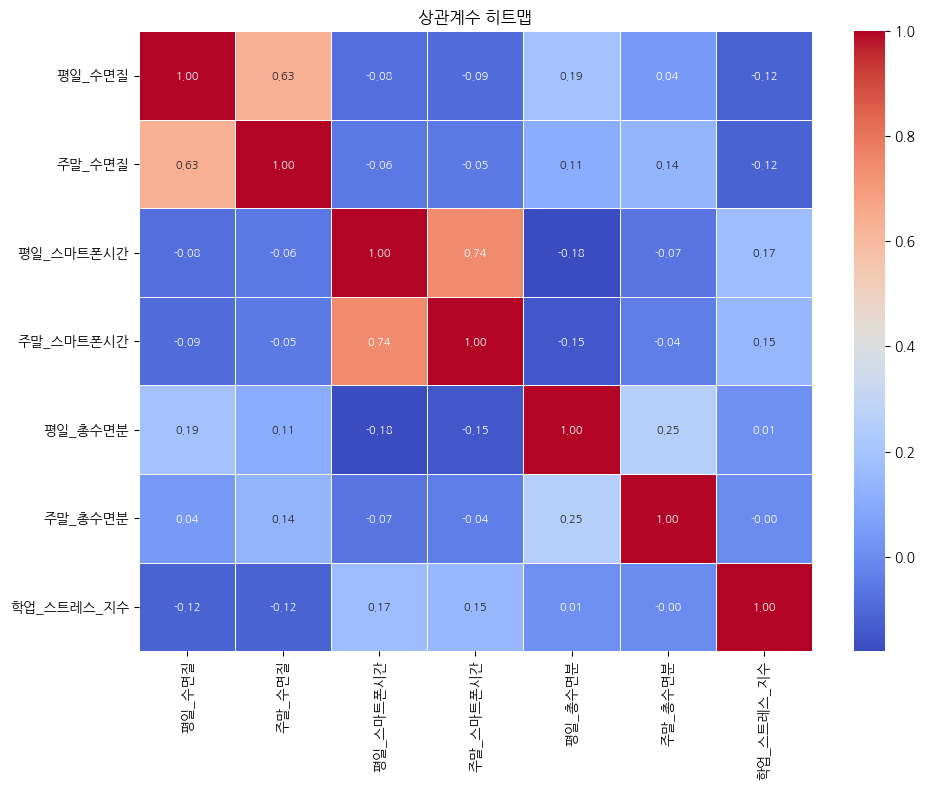

  저장: eda_corr_heatmap.png


In [31]:
corr_cols = [c for c in num_cols]
corr_mat = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, annot_kws={'size': 8})
ax.set_title('상관계수 히트맵')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(fig_dir, 'eda_corr_heatmap.png'), dpi=150)
plt.close()
print('  저장: eda_corr_heatmap.png')

## 수면질별 스트레스 박스플롯

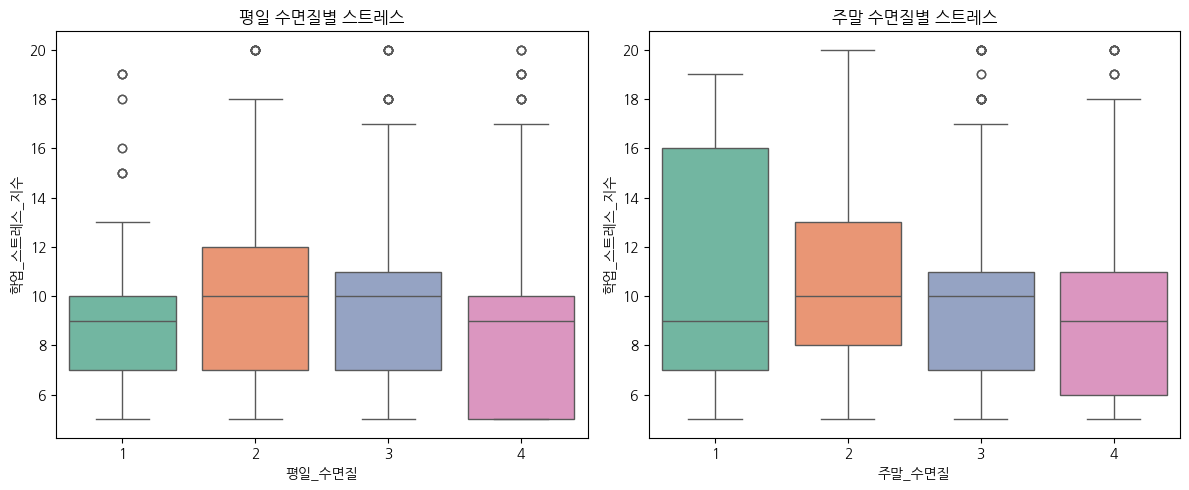

  저장: eda_box_sleepquality_vs_stress.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axes,
                           ['평일_수면질', '주말_수면질'],
                           ['평일 수면질별 스트레스', '주말 수면질별 스트레스']):
    sns.boxplot(x=col, y='학업_스트레스_지수', data=df, ax=ax, palette='Set2')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('학업_스트레스_지수')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(fig_dir, 'eda_box_sleepquality_vs_stress.png'), dpi=150)
plt.close()
print('  저장: eda_box_sleepquality_vs_stress.png')

## 스마트폰시간별 스트레스 박스플롯

  저장: eda_box_phone_vs_stress.png


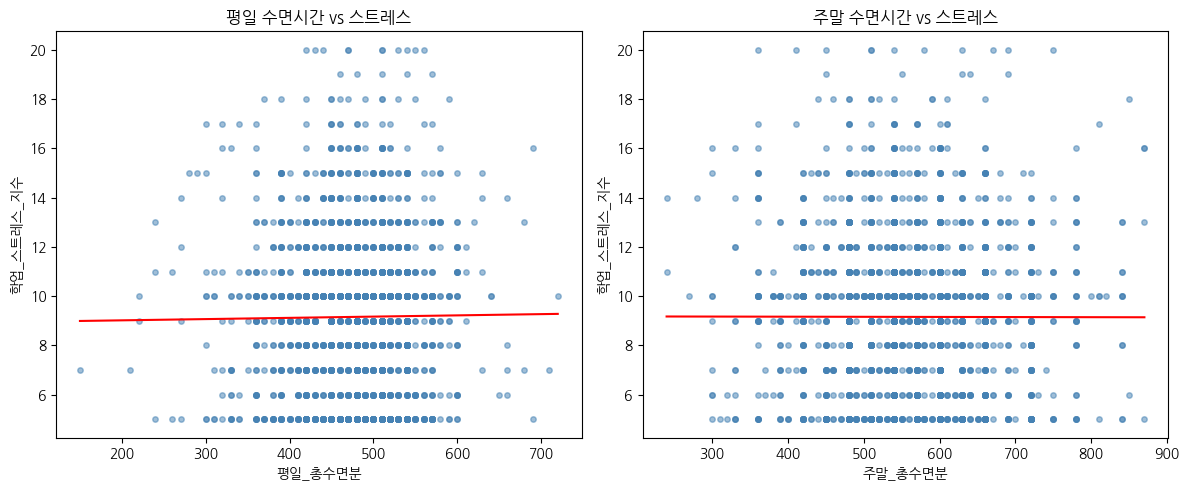

  저장: eda_scatter_sleepmin_vs_stress.png


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes,
                           ['평일_스마트폰시간', '주말_스마트폰시간'],
                           ['평일 스마트폰 시간별 스트레스', '주말 스마트폰 시간별 스트레스']):
    sns.boxplot(x=col, y='학업_스트레스_지수', data=df, ax=ax, palette='Set3')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('학업_스트레스_지수')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'eda_box_phone_vs_stress.png'), dpi=150)
plt.close()
print('  저장: eda_box_phone_vs_stress.png')

# 5) 수면시간 vs 스트레스 산점도
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axes,
                           ['평일_총수면분', '주말_총수면분'],
                           ['평일 수면시간 vs 스트레스', '주말 수면시간 vs 스트레스']):
    ax.scatter(df[col], df['학업_스트레스_지수'], alpha=0.3, s=15, color='steelblue')
    m, b = np.polyfit(df[col], df['학업_스트레스_지수'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('학업_스트레스_지수')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(fig_dir, 'eda_scatter_sleepmin_vs_stress.png'), dpi=150)
plt.close()
print('  저장: eda_scatter_sleepmin_vs_stress.png')

##  평일/주말 수면시간 바이올린

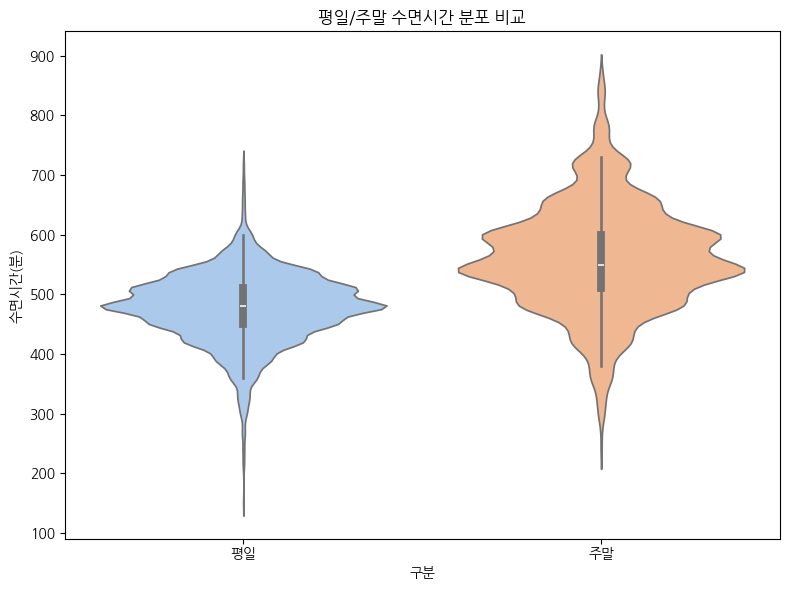

  저장: eda_violin_weekday_weekend.png


In [34]:
sleep_df = pd.DataFrame({
    '수면시간(분)': pd.concat([df['평일_총수면분'], df['주말_총수면분']], ignore_index=True),
    '구분': ['평일'] * len(df) + ['주말'] * len(df)
})
fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(x='구분', y='수면시간(분)', data=sleep_df, ax=ax, palette='pastel')
ax.set_title('평일/주말 수면시간 분포 비교')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'eda_violin_weekday_weekend.png'), dpi=150)
plt.show()
plt.close()
print('  저장: eda_violin_weekday_weekend.png')

## 상관계수 Pearson / Spearman

In [35]:
print('\n  Pearson/Spearman 상관 (vs 학업_스트레스_지수):')
for col in [c for c in num_cols if c != '학업_스트레스_지수']:
    pr, pp = stats.pearsonr(df[col], df['학업_스트레스_지수'])
    sr, sp = stats.spearmanr(df[col], df['학업_스트레스_지수'])
    print(f'    {col}: Pearson={pr:.3f}(p={pp:.4f}), Spearman={sr:.3f}(p={sp:.4f})')

# paired t-test (평일 vs 주말 수면시간)
t_stat, t_p = stats.ttest_rel(df['평일_총수면분'], df['주말_총수면분'])
print(f'\n  Paired t-test (평일 vs 주말 수면시간): t={t_stat:.4f}, p={t_p:.6f}')
if t_p < 0.05:
    print('  → 통계적으로 유의미한 차이 있음 (p < 0.05)')
else:
    print('  → 통계적으로 유의미한 차이 없음')


  Pearson/Spearman 상관 (vs 학업_스트레스_지수):
    평일_수면질: Pearson=-0.117(p=0.0000), Spearman=-0.113(p=0.0000)
    주말_수면질: Pearson=-0.119(p=0.0000), Spearman=-0.104(p=0.0000)
    평일_스마트폰시간: Pearson=0.170(p=0.0000), Spearman=0.171(p=0.0000)
    주말_스마트폰시간: Pearson=0.148(p=0.0000), Spearman=0.160(p=0.0000)
    평일_총수면분: Pearson=0.009(p=0.4976), Spearman=0.007(p=0.6353)
    주말_총수면분: Pearson=-0.001(p=0.9167), Spearman=0.001(p=0.9287)

  Paired t-test (평일 vs 주말 수면시간): t=-63.7924, p=0.000000
  → 통계적으로 유의미한 차이 있음 (p < 0.05)


##  피처 엔지니어링

In [36]:
print('\n[3] 피처 엔지니어링')
df = df.copy()
df['평균_수면질'] = (df['평일_수면질'] + df['주말_수면질']) / 2
df['평균_스마트폰'] = (df['평일_스마트폰시간'] + df['주말_스마트폰시간']) / 2
df['주간_총수면분'] = (df['평일_총수면분'] * 5 + df['주말_총수면분'] * 2) / 7
df['주말_보충수면'] = df['주말_총수면분'] - df['평일_총수면분']
df['수면질_차이'] = df['주말_수면질'] - df['평일_수면질']
df['스마트폰_과의존'] = df['평균_스마트폰'] / 4.0
df['수면부족플래그'] = (df['평일_총수면분'] < 420).astype(int)
df['수면효율'] = df['평균_수면질'] * (df['주간_총수면분'] / 60)

new_cols = ['평균_수면질', '평균_스마트폰', '주간_총수면분', '주말_보충수면',
            '수면질_차이', '스마트폰_과의존', '수면부족플래그', '수면효율']
print(f'  파생 피처 {len(new_cols)}개 생성: {new_cols}')
 


[3] 피처 엔지니어링
  파생 피처 8개 생성: ['평균_수면질', '평균_스마트폰', '주간_총수면분', '주말_보충수면', '수면질_차이', '스마트폰_과의존', '수면부족플래그', '수면효율']


#  회귀 분석

In [37]:
feature_cols = [
    '평일_수면질', '주말_수면질', '평일_스마트폰시간', '주말_스마트폰시간',
    '평일_총수면분', '주말_총수면분',
    '평균_수면질', '평균_스마트폰', '주간_총수면분', '주말_보충수면',
    '수면질_차이', '스마트폰_과의존', '수면부족플래그', '수면효율'
]
X = df[feature_cols]
y = df['학업_스트레스_지수']

# 60/20/20 분할
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE)
X_tv = pd.concat([X_train, X_val])
y_tv = pd.concat([y_train, y_val])

print(f'  Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

  Train: 3102, Val: 1034, Test: 1034


## 모델 및 파라미터 그리드 정의

In [39]:
models_config = {
    'LinearRegression': {
        'pipeline': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
        'param_grid': {}
    },
    'Ridge': {
        'pipeline': Pipeline([('scaler', StandardScaler()), ('model', Ridge())]),
        'param_grid': {'model__alpha': [0.01, 0.1, 1, 10, 100]}
    },
    'Lasso': {
        'pipeline': Pipeline([('scaler', StandardScaler()), ('model', Lasso(max_iter=10000))]),
        'param_grid': {'model__alpha': [0.001, 0.01, 0.1, 1.0]}
    },
    'RandomForest': {
        'pipeline': Pipeline([('model', RandomForestRegressor(random_state=RANDOM_STATE))]),
        'param_grid': {
            'model__n_estimators': [200, 500],
            'model__max_depth': [None, 8, 16],
            'model__min_samples_leaf': [1, 5, 10]
        }
    },
    'GradientBoosting': {
        'pipeline': Pipeline([('model', GradientBoostingRegressor(random_state=RANDOM_STATE))]),
        'param_grid': {
            'model__n_estimators': [100, 300],
            'model__learning_rate': [0.05, 0.1],
            'model__max_depth': [3, 5]
        }
    }
}

# 훈련하기

In [41]:
results = {}
trained_models = {}
cv_rmse_data = {}

for name, cfg in models_config.items():
    print(f'\n  [{name}] GridSearchCV 학습 중...')
    pipe = cfg['pipeline']
    grid = cfg['param_grid']

    if grid:
        gs = GridSearchCV(pipe, grid, cv=5, scoring='neg_mean_squared_error',
                          n_jobs=-1, refit=True)
        gs.fit(X_tv, y_tv)
        best_pipe = gs.best_estimator_
        print(f'    최적 파라미터: {gs.best_params_}')
    else:
        pipe.fit(X_tv, y_tv)
        best_pipe = pipe

    # 학습셋 예측
    y_train_pred = best_pipe.predict(X_train)
    # 테스트셋 예측
    y_test_pred = best_pipe.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae  = mean_absolute_error(y_train, y_train_pred)
    train_r2   = r2_score(y_train, y_train_pred)
    test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae   = mean_absolute_error(y_test, y_test_pred)
    test_r2    = r2_score(y_test, y_test_pred)

    # 5-fold CV RMSE
    cv_scores = cross_val_score(best_pipe, X_tv, y_tv, cv=5,
                                scoring='neg_mean_squared_error', n_jobs=-1)
    cv_rmse = np.sqrt(-cv_scores)
    cv_rmse_data[name] = cv_rmse

    results[name] = {
        'Train_RMSE': train_rmse, 'Train_MAE': train_mae, 'Train_R2': train_r2,
        'Test_RMSE': test_rmse,   'Test_MAE': test_mae,   'Test_R2': test_r2,
        'CV_RMSE_mean': cv_rmse.mean(), 'CV_RMSE_std': cv_rmse.std()
    }
    trained_models[name] = best_pipe

    print(f'    Train RMSE={train_rmse:.4f}, R²={train_r2:.4f}')
    print(f'    Test  RMSE={test_rmse:.4f}, R²={test_r2:.4f}')
    print(f'    CV RMSE={cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}')

    # 모델 저장
    mdl_dir = MDL_DIR 
    mdl_path = os.path.join(mdl_dir, f'reg_{name}.pkl')
    joblib.dump(best_pipe, mdl_path)
    print(f'    모델 저장: {mdl_path}')


  [LinearRegression] GridSearchCV 학습 중...
    Train RMSE=2.9791, R²=0.0487
    Test  RMSE=3.0742, R²=0.0171
    CV RMSE=3.0190 ± 0.0688
    모델 저장: D:\KCYPS2018/models/reg_LinearRegression.pkl

  [Ridge] GridSearchCV 학습 중...
    최적 파라미터: {'model__alpha': 100}
    Train RMSE=2.9792, R²=0.0487
    Test  RMSE=3.0728, R²=0.0180
    CV RMSE=3.0186 ± 0.0685
    모델 저장: D:\KCYPS2018/models/reg_Ridge.pkl

  [Lasso] GridSearchCV 학습 중...
    최적 파라미터: {'model__alpha': 0.01}
    Train RMSE=2.9788, R²=0.0489
    Test  RMSE=3.0725, R²=0.0182
    CV RMSE=3.0183 ± 0.0690
    모델 저장: D:\KCYPS2018/models/reg_Lasso.pkl

  [RandomForest] GridSearchCV 학습 중...
    최적 파라미터: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 500}
    Train RMSE=1.1145, R²=0.8669
    Test  RMSE=2.0380, R²=0.5680
    CV RMSE=2.3236 ± 0.0788
    모델 저장: D:\KCYPS2018/models/reg_RandomForest.pkl

  [GradientBoosting] GridSearchCV 학습 중...
    최적 파라미터: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'm

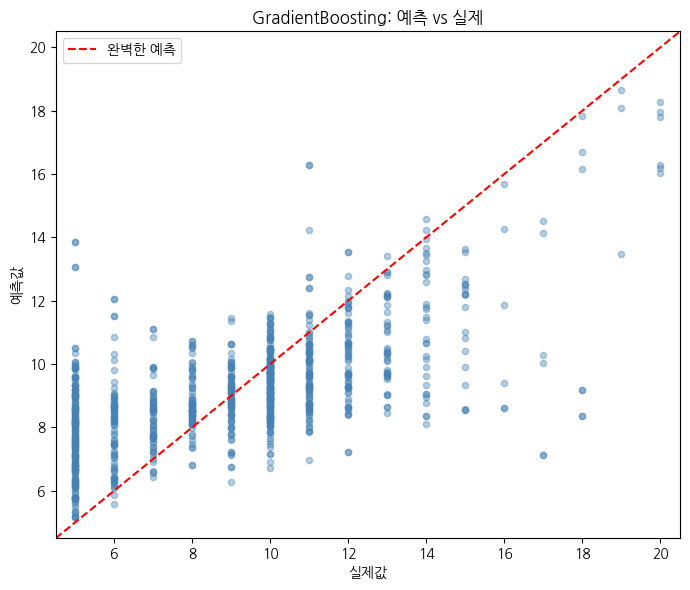

In [42]:
# 예측 vs 실제 그래프
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_test_pred, alpha=0.4, s=20, color='steelblue')
lim = [min(y_test.min(), y_test_pred.min()) - 0.5,
       max(y_test.max(), y_test_pred.max()) + 0.5]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='완벽한 예측')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('실제값'); ax.set_ylabel('예측값')
ax.set_title(f'{name}: 예측 vs 실제')
ax.legend()
plt.tight_layout()
plt.show( )
plt.savefig(os.path.join(fig_dir, f'reg_pred_vs_actual_{name}.png'), dpi=150)
plt.close()

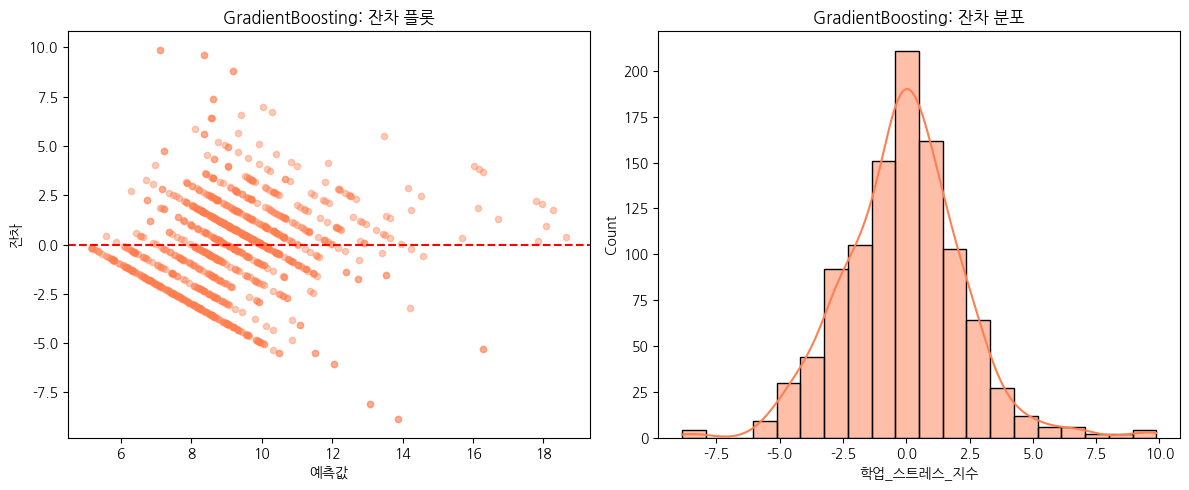

In [43]:
# 잔차 그래프
residuals = y_test - y_test_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test_pred, residuals, alpha=0.4, s=20, color='coral')
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('예측값'); axes[0].set_ylabel('잔차')
axes[0].set_title(f'{name}: 잔차 플롯')
sns.histplot(residuals, kde=True, ax=axes[1], color='coral', bins=20)
axes[1].set_title(f'{name}: 잔차 분포')
plt.tight_layout()
plt.show( )
plt.savefig(os.path.join(fig_dir, f'reg_residual_{name}.png'), dpi=150)
plt.close()

In [46]:
# 결과 저장

results_df = pd.DataFrame(results).T.round(4)
out_dir = OUT_DIR
results_df.to_csv(os.path.join(out_dir, 'reg_metrics_table.csv'), encoding='utf-8-sig')
print(f'\n  회귀 결과 저장: {os.path.join(out_dir, "reg_metrics_table.csv")}')
print('\n  === 회귀 성능 요약 ===')
print(results_df.to_string())


  회귀 결과 저장: D:\KCYPS2018/outputs/reg_metrics_table.csv

  === 회귀 성능 요약 ===
                  Train_RMSE  Train_MAE  Train_R2  Test_RMSE  Test_MAE  Test_R2  CV_RMSE_mean  CV_RMSE_std
LinearRegression      2.9791     2.3794    0.0487     3.0742    2.4490   0.0171        3.0190       0.0688
Ridge                 2.9792     2.3798    0.0487     3.0728    2.4483   0.0180        3.0186       0.0685
Lasso                 2.9788     2.3796    0.0489     3.0725    2.4486   0.0182        3.0183       0.0690
RandomForest          1.1145     0.7080    0.8669     2.0380    1.4480   0.5680        2.3236       0.0788
GradientBoosting      1.7553     1.3160    0.6698     2.3622    1.7780   0.4196        2.5343       0.1029


# 결과 시각화

  저장: reg_cv_rmse_box.png
  저장: reg_model_comparison.png


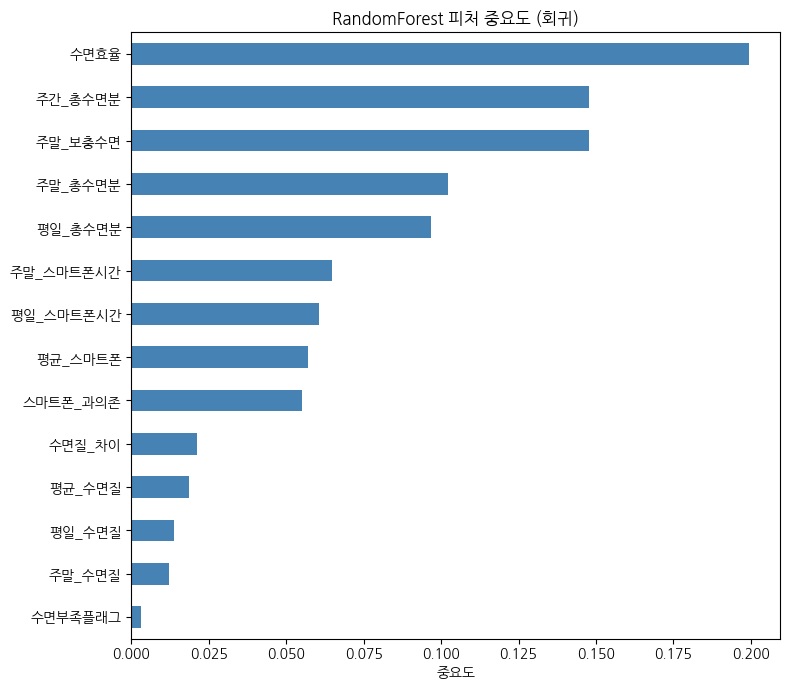

  저장: reg_feature_importance_rf.png


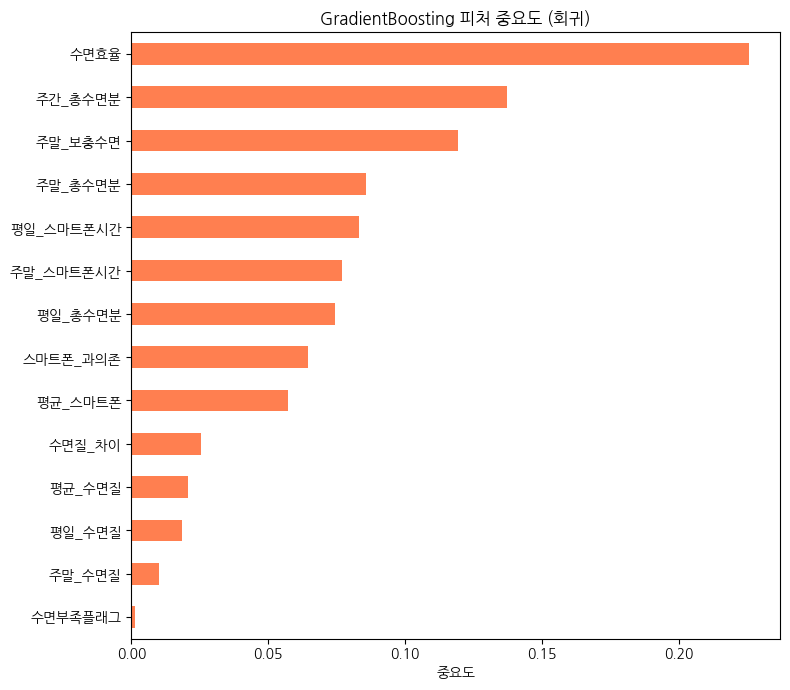

  저장: reg_feature_importance_gbm.png


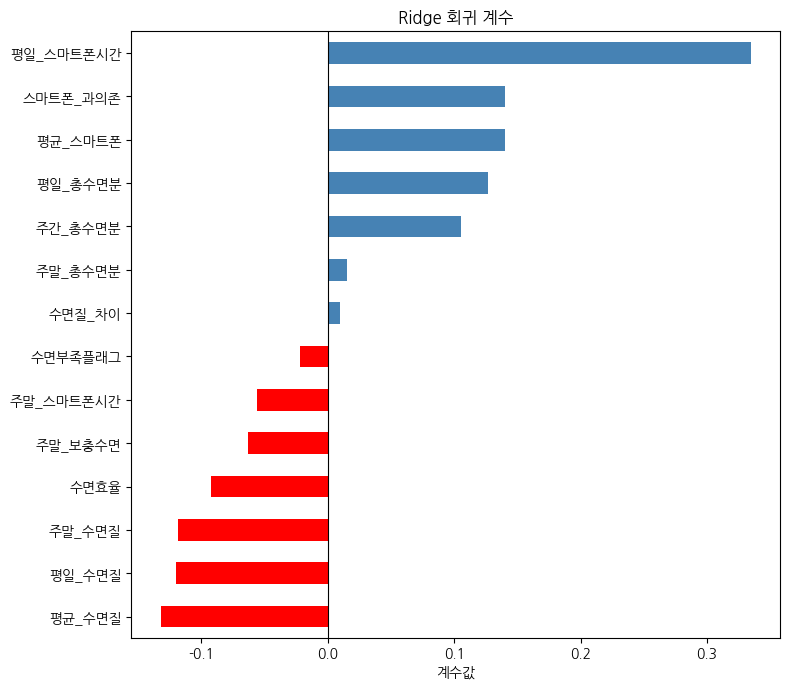

  저장: reg_coef_ridge.png

  회귀 최고 모델 (Test R² 기준): RandomForest (R²=0.5680)


In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([cv_rmse_data[n] for n in results.keys()],
           labels=list(results.keys()), patch_artist=True)
ax.set_title('모델별 5-fold CV RMSE 비교')
ax.set_ylabel('RMSE')
ax.set_xticklabels(list(results.keys()), rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'reg_cv_rmse_box.png'), dpi=150)
plt.close()
print('  저장: reg_cv_rmse_box.png')

# 모델 비교 막대그래프
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names = list(results.keys())
metrics = ['Test_RMSE', 'Test_MAE', 'Test_R2']
titles = ['Test RMSE (낮을수록 좋음)', 'Test MAE (낮을수록 좋음)', 'Test R² (높을수록 좋음)']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
for ax, metric, title in zip(axes, metrics, titles):
    vals = [results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=colors)
    ax.set_title(title)
    ax.set_xticklabels(names, rotation=15, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'reg_model_comparison.png'), dpi=150)
plt.close()
print('  저장: reg_model_comparison.png')

# RF 피처 중요도
rf_model = trained_models['RandomForest']
rf_importances = rf_model.named_steps['model'].feature_importances_
rf_fi = pd.Series(rf_importances, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 7))
rf_fi.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('RandomForest 피처 중요도 (회귀)')
ax.set_xlabel('중요도')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(fig_dir, 'reg_feature_importance_rf.png'), dpi=150)
plt.close()
print('  저장: reg_feature_importance_rf.png')

# GBM 피처 중요도
gbm_model = trained_models['GradientBoosting']
gbm_importances = gbm_model.named_steps['model'].feature_importances_
gbm_fi = pd.Series(gbm_importances, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 7))
gbm_fi.plot(kind='barh', ax=ax, color='coral')
ax.set_title('GradientBoosting 피처 중요도 (회귀)')
ax.set_xlabel('중요도')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(fig_dir, 'reg_feature_importance_gbm.png'), dpi=150)
plt.close()
print('  저장: reg_feature_importance_gbm.png')

# Ridge 계수
ridge_model = trained_models['Ridge']
ridge_coefs = ridge_model.named_steps['model'].coef_
ridge_coef_s = pd.Series(ridge_coefs, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
colors_coef = ['red' if v < 0 else 'steelblue' for v in ridge_coef_s.values]
ridge_coef_s.plot(kind='barh', ax=ax, color=colors_coef)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ridge 회귀 계수')
ax.set_xlabel('계수값')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(fig_dir, 'reg_coef_ridge.png'), dpi=150)
plt.close()
print('  저장: reg_coef_ridge.png')

# 최고 모델 선택 (Test_R2 기준)
best_model_name = max(results, key=lambda n: results[n]['Test_R2'])
print(f'\n  회귀 최고 모델 (Test R² 기준): {best_model_name} (R²={results[best_model_name]["Test_R2"]:.4f})')

##  분류 분석

In [52]:
df

,ID,평일_수면질,주말_수면질,평일_스마트폰시간,주말_스마트폰시간,평일_총수면분,주말_총수면분,학업_스트레스_지수,평균_수면질,평균_스마트폰,주간_총수면분,주말_보충수면,수면질_차이,스마트폰_과의존,수면부족플래그,수면효율
0,7802,3,4,6,7,500,630,5,3.5,6.5,537.142857,130,1,1.625,0,31.333333
1,11922,1,1,5,6,540,640,19,1.0,5.5,568.571429,100,0,1.375,0,9.476190
2,11932,4,4,4,5,560,690,5,4.0,4.5,597.142857,130,0,1.125,0,39.809524
3,12852,4,4,2,3,580,630,13,4.0,2.5,594.285714,50,0,0.625,0,39.619048
4,15902,4,4,6,6,480,530,5,4.0,6.0,494.285714,50,0,1.500,0,32.952381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5165,51571,2,3,6,7,480,420,13,2.5,6.5,462.857143,-60,1,1.625,0,19.285714
5166,51581,3,3,2,2,510,660,5,3.0,2.0,552.857143,150,0,0.500,0,27.642857
5167,51591,4,4,5,6,580,620,8,4.0,5.5,591.428571,40,0,1.375,0,39.428571
5168,51601,4,4,5,6,510,490,5,4.0,5.5,504.285714,-20,0,1.375,0,33.619048


- 임계값 결정하기

In [54]:
def determine_threshold(y):
    print('\n[5-1] 분류 임계값 결정')
    q75 = y.quantile(0.75)
    mean_std = y.mean() + y.std()
    fixed = 12
    print(f'  75분위: {q75:.2f}')
    print(f'  평균+1std: {mean_std:.2f}')
    print(f'  고정값: {fixed}')

    # 각 임계값의 positive 비율
    for thr, label in [(q75, '75분위'), (mean_std, '평균+1std'), (fixed, '고정값12')]:
        ratio = (y >= thr).mean()
        print(f'  {label} (임계={thr:.2f}): positive 비율={ratio:.3f}')

    threshold = q75
    print(f'  선택된 임계값: {threshold:.2f} (75분위)')
    return threshold
threshold = determine_threshold(df['학업_스트레스_지수'])
print(threshold)


[5-1] 분류 임계값 결정
  75분위: 11.00
  평균+1std: 12.26
  고정값: 12
  75분위 (임계=11.00): positive 비율=0.285
  평균+1std (임계=12.26): positive 비율=0.133
  고정값12 (임계=12.00): positive 비율=0.193
  선택된 임계값: 11.00 (75분위)
11.0



[5-2] 분류 분석 (임계값=11.00)
  클래스 분포: 0=3698, 1=1472, 비율=0.285


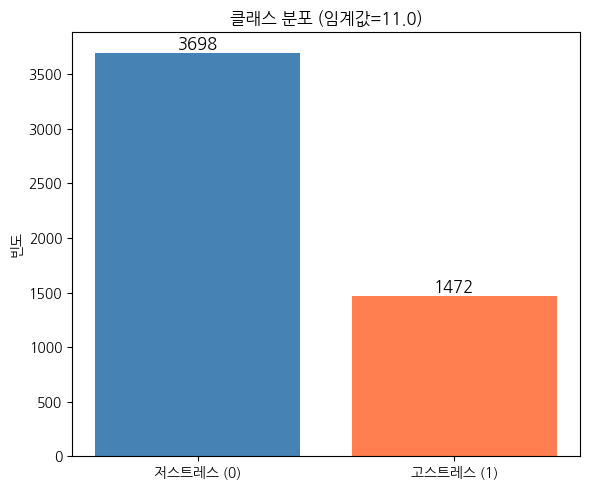

  저장: cls_class_balance.png


In [56]:
print(f'\n[5-2] 분류 분석 (임계값={threshold:.2f})')

feature_cols = [
    '평일_수면질', '주말_수면질', '평일_스마트폰시간', '주말_스마트폰시간',
    '평일_총수면분', '주말_총수면분',
    '평균_수면질', '평균_스마트폰', '주간_총수면분', '주말_보충수면',
    '수면질_차이', '스마트폰_과의존', '수면부족플래그', '수면효율'
]

X = df[feature_cols]
y_bin = (df['학업_스트레스_지수'] >= threshold).astype(int)

print(f'  클래스 분포: 0={( y_bin==0).sum()}, 1={(y_bin==1).sum()}, 비율={y_bin.mean():.3f}')

# 클래스 균형 시각화
fig, ax = plt.subplots(figsize=(6, 5))
class_counts = y_bin.value_counts().sort_index()
bars = ax.bar(['저스트레스 (0)', '고스트레스 (1)'], class_counts.values,
              color=['steelblue', 'coral'])
for bar, v in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(v), ha='center', va='bottom', fontsize=12)
ax.set_title(f'클래스 분포 (임계값={threshold:.1f})')
ax.set_ylabel('빈도')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(fig_dir, 'cls_class_balance.png'), dpi=150)
plt.close()
print('  저장: cls_class_balance.png')

## 분할

In [57]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y_bin, test_size=0.2,
                                                   random_state=RANDOM_STATE, stratify=y_bin)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25,
                                                   random_state=RANDOM_STATE, stratify=y_temp)
X_tv = pd.concat([X_train, X_val])
y_tv = pd.concat([y_train, y_val])

print(f'  Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

  Train: 3102, Val: 1034, Test: 1034


## 모델 정의

In [58]:
cls_configs = {
    'LogisticRegression': {
        'pipeline': Pipeline([('scaler', StandardScaler()),
                              ('model', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
        'param_grid': {'model__C': [0.01, 0.1, 1.0, 10.0]}
    },
    'RandomForest': {
        'pipeline': Pipeline([('model', RandomForestClassifier(random_state=RANDOM_STATE))]),
        'param_grid': {
            'model__n_estimators': [200, 500],
            'model__max_depth': [None, 8, 16],
            'model__min_samples_leaf': [1, 5]
        }
    },
    'GradientBoosting': {
        'pipeline': Pipeline([('model', GradientBoostingClassifier(random_state=RANDOM_STATE))]),
        'param_grid': {
            'model__n_estimators': [100, 300],
            'model__learning_rate': [0.05, 0.1],
            'model__max_depth': [3, 5]
        }
    },
    'SVC': {
        'pipeline': Pipeline([('scaler', StandardScaler()),
                              ('model', SVC(probability=True, random_state=RANDOM_STATE))]),
        'param_grid': {
            'model__C': [0.1, 1.0, 10.0],
            'model__kernel': ['rbf', 'linear']
        }
    }
}


  [LogisticRegression] GridSearchCV 학습 중...
    최적 파라미터: {'model__C': 0.1}
    Acc=0.7195, Prec=0.6429, Rec=0.0306, F1=0.0584, AUC=0.6032


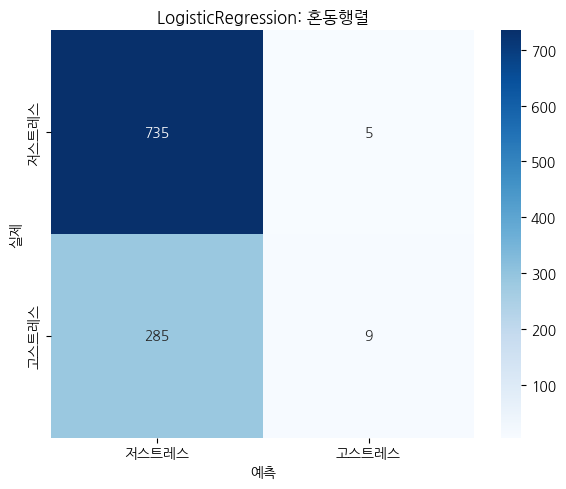

    저장: cls_confusion_matrix_LogisticRegression.png

  [RandomForest] GridSearchCV 학습 중...
    최적 파라미터: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
    Acc=0.8598, Prec=0.7729, Rec=0.7177, F1=0.7443, AUC=0.9138


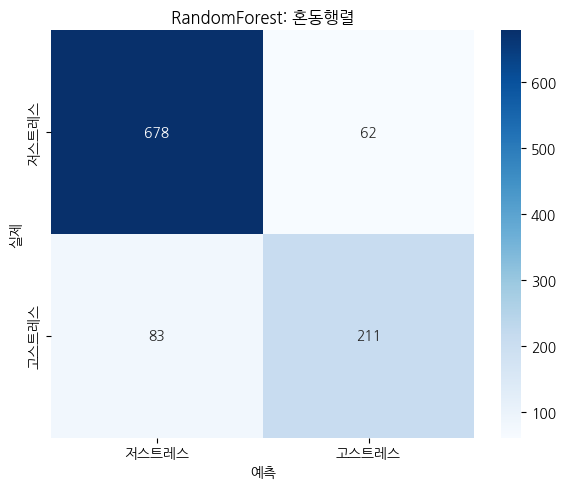

    저장: cls_confusion_matrix_RandomForest.png

  [GradientBoosting] GridSearchCV 학습 중...
    최적 파라미터: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 300}
    Acc=0.8172, Prec=0.7692, Rec=0.5102, F1=0.6135, AUC=0.8502


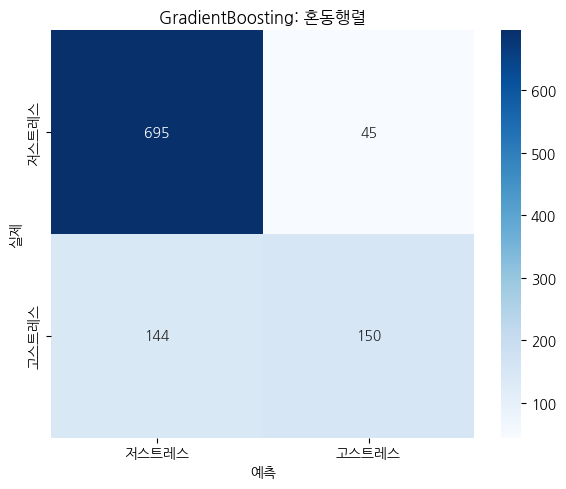

    저장: cls_confusion_matrix_GradientBoosting.png

  [SVC] GridSearchCV 학습 중...
    최적 파라미터: {'model__C': 10.0, 'model__kernel': 'rbf'}
    Acc=0.7282, Prec=0.5783, Rec=0.1633, F1=0.2546, AUC=0.6223


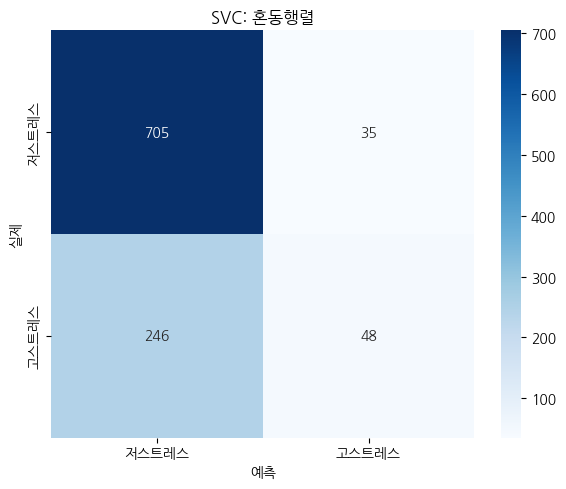

    저장: cls_confusion_matrix_SVC.png


In [59]:
results = {}
trained_models = {}
roc_data = {}

for name, cfg in cls_configs.items():
    print(f'\n  [{name}] GridSearchCV 학습 중...')
    pipe = cfg['pipeline']
    grid = cfg['param_grid']

    gs = GridSearchCV(pipe, grid, cv=5, scoring='f1', n_jobs=-1, refit=True)
    gs.fit(X_tv, y_tv)
    best_pipe = gs.best_estimator_
    print(f'    최적 파라미터: {gs.best_params_}')

    y_pred = best_pipe.predict(X_test)
    y_prob = best_pipe.predict_proba(X_test)[:, 1]

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, zero_division=0)
    rec   = recall_score(y_test, y_pred, zero_division=0)
    f1    = f1_score(y_test, y_pred, zero_division=0)
    auc   = roc_auc_score(y_test, y_prob)

    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC_ROC': auc
    }
    trained_models[name] = best_pipe

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, auc)

    print(f'    Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, AUC={auc:.4f}')

    # 모델 저장
    joblib.dump(best_pipe, os.path.join(mdl_dir, f'cls_{name}.pkl'))

    # 혼동행렬
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['저스트레스', '고스트레스'],
                yticklabels=['저스트레스', '고스트레스'])
    ax.set_title(f'{name}: 혼동행렬')
    ax.set_ylabel('실제'); ax.set_xlabel('예측')
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(fig_dir, f'cls_confusion_matrix_{name}.png'), dpi=150)
    plt.close()
    print(f'    저장: cls_confusion_matrix_{name}.png')

## ROC곡선 - AUC 

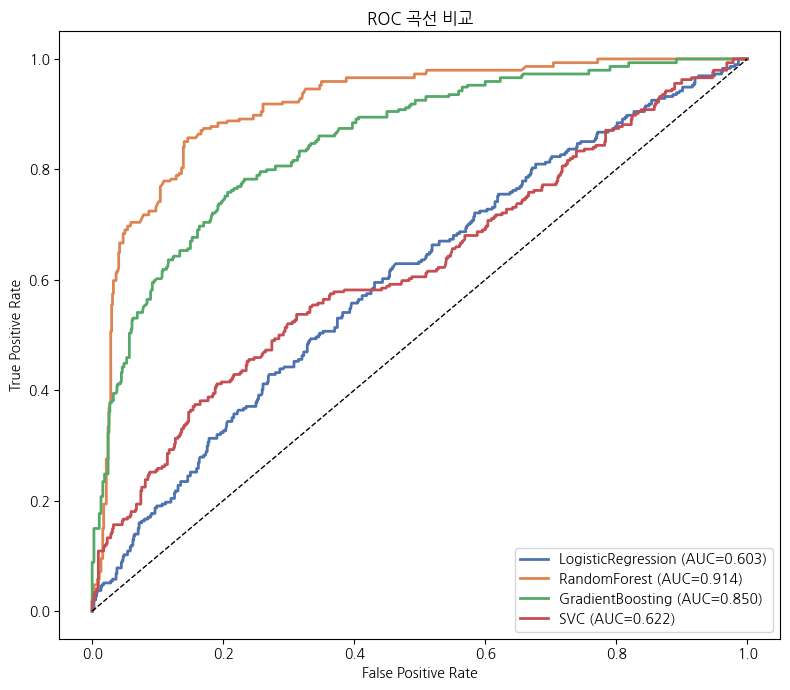

  저장: cls_roc_curve.png


In [60]:
# ROC 곡선 통합
fig, ax = plt.subplots(figsize=(8, 7))
colors_roc = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for (name, (fpr, tpr, auc)), color in zip(roc_data.items(), colors_roc):
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC 곡선 비교')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(fig_dir, 'cls_roc_curve.png'), dpi=150)
plt.close()
print('  저장: cls_roc_curve.png')

# 피처 중요도

- RandomForest 피처 중요도

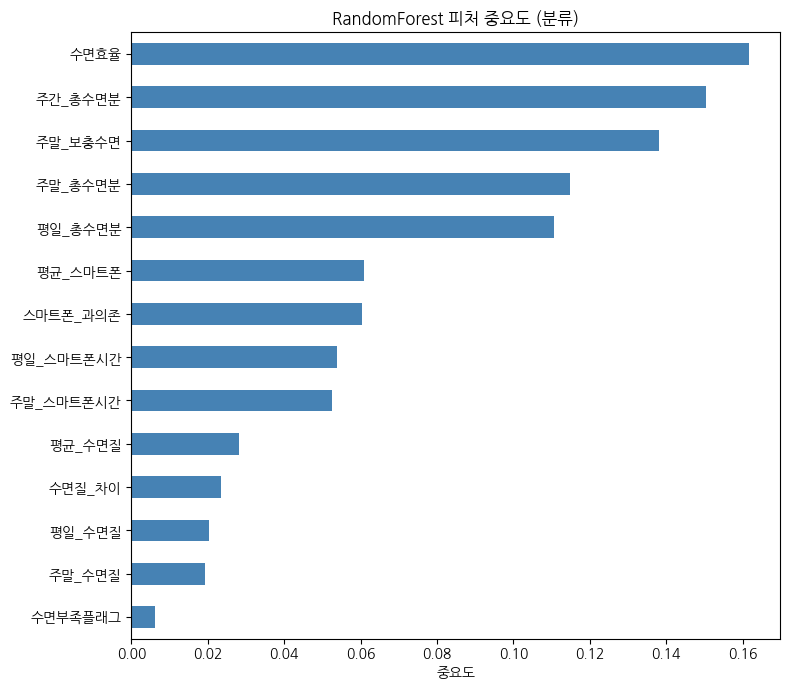

  저장: cls_feature_importance_rf.png


In [61]:
rf_cls = trained_models['RandomForest']
rf_imp = rf_cls.named_steps['model'].feature_importances_
rf_fi = pd.Series(rf_imp, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 7))
rf_fi.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('RandomForest 피처 중요도 (분류)')
ax.set_xlabel('중요도')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(fig_dir, 'cls_feature_importance_rf.png'), dpi=150)
plt.close()
print('  저장: cls_feature_importance_rf.png')

-  부스팅 피처 중요도

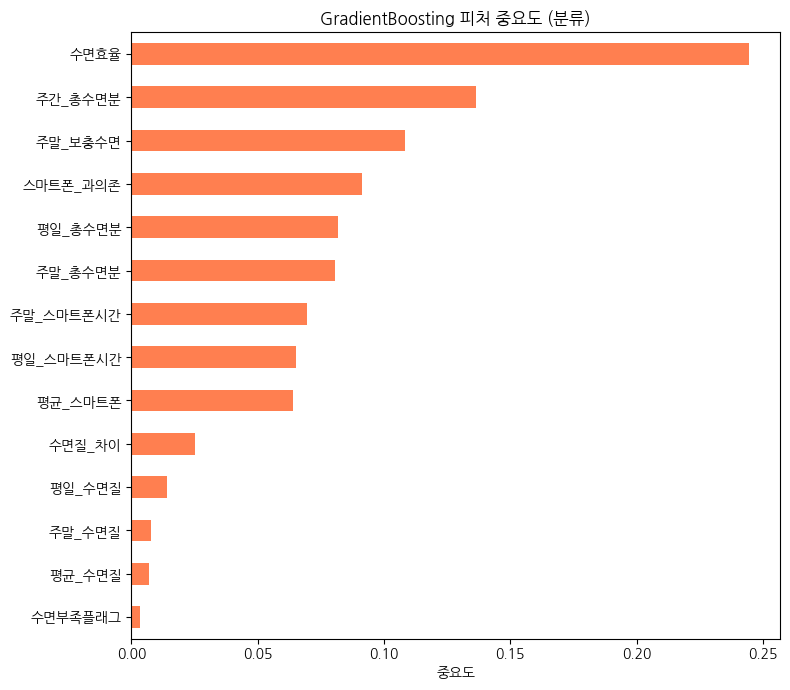

  저장: cls_feature_importance_gbm.png


In [62]:
gbm_cls = trained_models['GradientBoosting']
gbm_imp = gbm_cls.named_steps['model'].feature_importances_
gbm_fi = pd.Series(gbm_imp, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 7))
gbm_fi.plot(kind='barh', ax=ax, color='coral')
ax.set_title('GradientBoosting 피처 중요도 (분류)')
ax.set_xlabel('중요도')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(fig_dir, 'cls_feature_importance_gbm.png'), dpi=150)
plt.close()
print('  저장: cls_feature_importance_gbm.png')

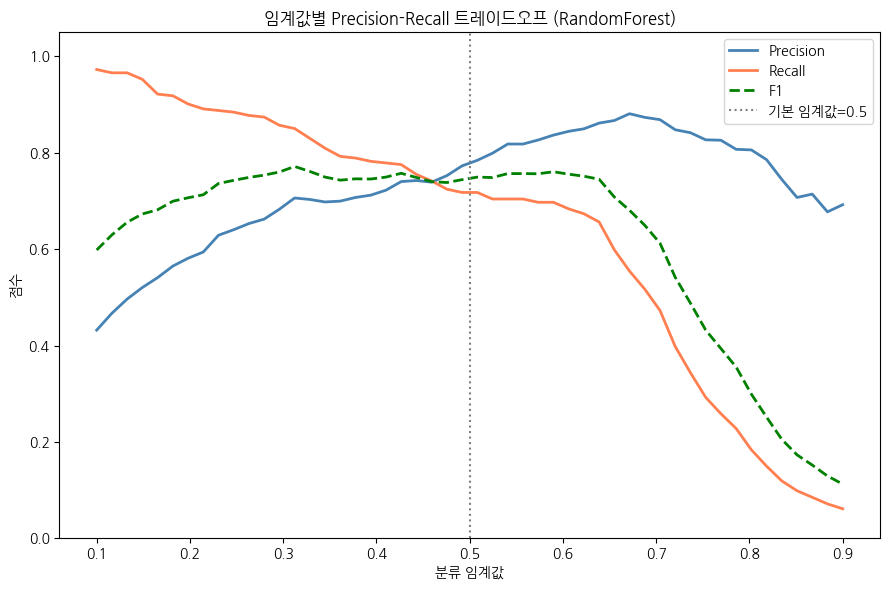

  저장: cls_threshold_sweep.png


In [63]:
# 임계값 스윕 (Precision-Recall 트레이드오프)
best_cls_name = max(results, key=lambda n: results[n]['F1'])
best_cls_model = trained_models[best_cls_name]
y_prob_best = best_cls_model.predict_proba(X_test)[:, 1]

thresholds_sweep = np.linspace(0.1, 0.9, 50)
precisions, recalls, f1s = [], [], []
for thr in thresholds_sweep:
    y_pred_t = (y_prob_best >= thr).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(thresholds_sweep, precisions, label='Precision', color='steelblue', lw=2)
ax.plot(thresholds_sweep, recalls, label='Recall', color='coral', lw=2)
ax.plot(thresholds_sweep, f1s, label='F1', color='green', lw=2, linestyle='--')
ax.axvline(0.5, color='gray', linestyle=':', lw=1.5, label='기본 임계값=0.5')
ax.set_xlabel('분류 임계값')
ax.set_ylabel('점수')
ax.set_title(f'임계값별 Precision-Recall 트레이드오프 ({best_cls_name})')
ax.legend()
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(fig_dir, 'cls_threshold_sweep.png'), dpi=150)
plt.close()
print('  저장: cls_threshold_sweep.png')

In [65]:
# 결과 저장
results_df = pd.DataFrame(results).T.round(4)
results_df.to_csv(os.path.join(out_dir, 'cls_metrics_table.csv'), encoding='utf-8-sig')
print(f'\n  분류 결과 저장: {os.path.join(out_dir, "cls_metrics_table.csv")}')
print('\n  === 분류 성능 요약 ===')
print(results_df.to_string())

best_model_name = max(results, key=lambda n: results[n]['F1'])
print(f'\n  분류 최고 모델 (F1 기준): {best_model_name} (F1={results[best_model_name]["F1"]:.4f})')



  분류 결과 저장: D:\KCYPS2018/outputs/cls_metrics_table.csv

  === 분류 성능 요약 ===
                    Accuracy  Precision  Recall      F1  AUC_ROC
LogisticRegression    0.7195     0.6429  0.0306  0.0584   0.6032
RandomForest          0.8598     0.7729  0.7177  0.7443   0.9138
GradientBoosting      0.8172     0.7692  0.5102  0.6135   0.8502
SVC                   0.7282     0.5783  0.1633  0.2546   0.6223

  분류 최고 모델 (F1 기준): RandomForest (F1=0.7443)
